In [2]:
import numpy as np
import matplotlib.pyplot as plt
from disba import PhaseDispersion, depthplot
import subfunctions as sf
from Least_squares import invert_dispersion_ls

# Reproducibility for synthetic noise
np.random.seed(42)

In [3]:
# Synthetic dispersion data generation

velocity_model = np.array([
    [20.0, 600.0,  300.0, 2000.0],
    [40.0, 1400.0,  700.0, 2000.0],
    [ 0.0, 2000.0, 1000.0, 2000.0],
]) * 1.0e-3  # convert from (m, m/s, m/s, kg/m^3) to (km, km/s, km/s, g/cc)-like scale

# Thickness array for plotting (use a dummy last layer thickness for depthplot)
thk_true = np.append(velocity_model[:-1, 0].copy(), 1.0)
vs_true  = velocity_model[:, 2].copy()

# Period sampling (s)
# Here we create frequencies 3~10 Hz and convert to periods (reversed)
f = np.linspace(1.0, 10.0, 20)     # Hz
periods = 1.0 / f[::-1]            # s (ascending)

pd = PhaseDispersion(*velocity_model.T)
cpr = pd(periods, mode=0, wave="rayleigh")

syn_period = cpr.period
syn_velocity = cpr.velocity + 0.01 * np.random.randn(len(cpr.velocity))  # add noise

`xtol` termination condition is satisfied.
Function evaluations 21, initial cost 4.6329e-02, final cost 4.3211e-02, first-order optimality 8.08e-01.

=== Inversion result ===
success: True
message: `xtol` termination condition is satisfied.
x0     : [0.01 0.04 0.2  0.6  1.1 ]
x_inv  : [0.01017193 0.0405854  0.19929024 0.59971173 1.09945931]

Inverted model [thk vp vs rho]:
 [[0.01017193 0.39858047 0.19929024 2.        ]
 [0.0405854  1.19942345 0.59971173 2.        ]
 [0.         2.19891862 1.09945931 2.        ]]


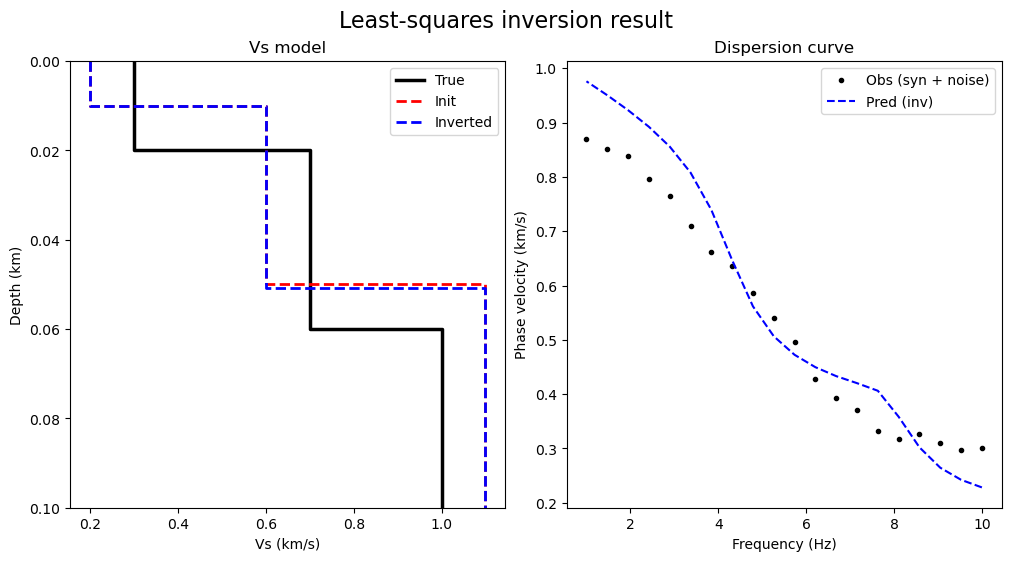

In [3]:
# An example of performing least-squares inversion

# Initial guess (example)
# parameters = [thk(n-1), vs(n)]
mode = 0

thk0 = np.array([0.01,0.04])     # km the thickness of the half-space is not needed
vs0  = np.array([0.2, 0.6, 1.1]) # km/s 
n_layers = len(vs0)

x0 = np.r_[thk0, vs0]

res, model_inv = invert_dispersion_ls(
    observed_periods=syn_period,
    observed_velocity=syn_velocity,
    mode=mode,
    x0=x0,
    n_layers=n_layers,
    method="trf",     # change to "lm" if you want (no bounds)
    verbose=1
)

print("\n=== Inversion result ===")
print("success:", res.success)
print("message:", res.message)
print("x0     :", x0)
print("x_inv  :", res.x)
print("\nInverted model [thk vp vs rho]:\n", model_inv)


# Convert parameter vectors to thickness/vs for plotting
thk_init, vs_init = sf.params2_thk_vs(x0)
thk_inv,  vs_inv  = sf.params2_thk_vs(res.x)

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), constrained_layout=True)
fig.suptitle("Least-squares inversion result", fontsize=16)
# (1) Vs-depth model comparison
ax0 = axes[0]
depthplot(thk_true, vs_true, ax=ax0, plot_args={"color": "k", "linewidth": 2.5, "linestyle": "-"})
depthplot(thk_init, vs_init, ax=ax0, plot_args={"color": "r", "linewidth": 2.0, "linestyle": "--"})
depthplot(thk_inv,  vs_inv,  ax=ax0, plot_args={"color": "b", "linewidth": 2.0, "linestyle": "--"})
ax0.set_title("Vs model")
ax0.set_ylim(0.1, 0.0)
ax0.legend(["True", "Init", "Inverted"], loc="best")
ax0.set_xlabel("Vs (km/s)")
ax0.set_ylabel("Depth (km)")


# (2) Dispersion curve comparison
pred_init = sf.forward_disp(x0,    syn_period, mode=mode)
pred_inv  = sf.forward_disp(res.x, syn_period, mode=mode)

ax1 = axes[1]
ax1.plot(1.0 / syn_period, syn_velocity, "k.", label="Obs (syn + noise)")
#ax1.plot(1.0 / syn_period, pred_init,    "r-", label="Pred (init)")
ax1.plot(1.0 / syn_period, pred_inv,     "b--", label="Pred (inv)")
ax1.set_title("Dispersion curve")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Phase velocity (km/s)")
ax1.legend(loc="best")

plt.savefig("ls_inversion_result.png", dpi=150)
plt.show()

Optimization terminated successfully.
         Current function value: 0.000883
         Iterations: 21
         Function evaluations: 27
         Gradient evaluations: 27

=== Inversion result ===
success: True
message: Optimization terminated successfully.
x0     : [0.01 0.04 0.2  0.6  1.1 ]
x_inv  : [0.02069689 0.04594091 0.30674586 0.72128945 0.9926852 ]

Inverted model [thk vp vs rho]:
 [[0.02069689 0.61349172 0.30674586 2.        ]
 [0.04594091 1.44257889 0.72128945 2.        ]
 [0.         1.9853704  0.9926852  2.        ]]


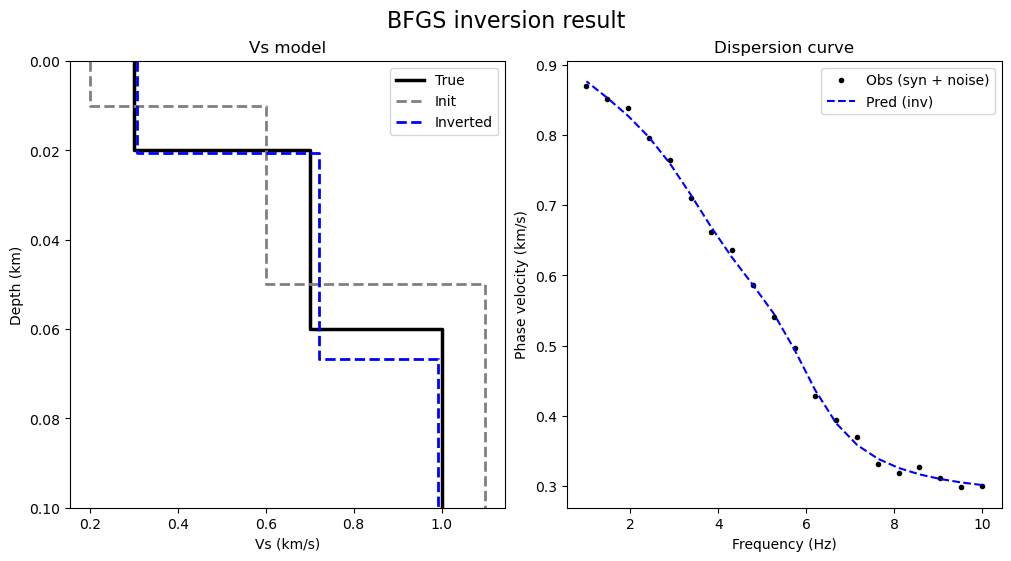

In [ ]:
from BFGS import invert_dispersion_bfgs
# An example of performing BFGS inversion

# Initial guess (example)
# parameters = [thk(n-1), vs(n)]
mode = 0

thk0 = np.array([0.01,0.04])     # km the thickness of the half-space is not needed
vs0  = np.array([0.2, 0.6, 1.1]) # km/s 
n_layers = len(vs0)

x0 = np.r_[thk0, vs0]

res, model_inv = invert_dispersion_bfgs(
    observed_periods=syn_period,
    observed_velocity=syn_velocity,
    mode=mode,
    x0=x0,
    n_layers=n_layers,
)

print("\n=== Inversion result ===")
print("success:", res.success)
print("message:", res.message)
print("x0     :", x0)
print("x_inv  :", res.x)
print("\nInverted model [thk vp vs rho]:\n", model_inv)


# Convert parameter vectors to thickness/vs for plotting
thk_init, vs_init = sf.params2_thk_vs(x0)
thk_inv,  vs_inv  = sf.params2_thk_vs(res.x)

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), constrained_layout=True)
fig.suptitle("BFGS inversion result", fontsize=16)
# (1) Vs-depth model comparison
ax0 = axes[0]
depthplot(thk_true, vs_true, ax=ax0, plot_args={"color": "k", "linewidth": 2.5, "linestyle": "-"})
depthplot(thk_init, vs_init, ax=ax0, plot_args={"color": "gray", "linewidth": 2.0, "linestyle": "--"})
depthplot(thk_inv,  vs_inv,  ax=ax0, plot_args={"color": "b", "linewidth": 2.0, "linestyle": "--"})
ax0.set_title("Vs model")
ax0.set_ylim(0.1, 0.0)
ax0.legend(["True", "Init", "Inverted"], loc="best")
ax0.set_xlabel("Vs (km/s)")
ax0.set_ylabel("Depth (km)")


# (2) Dispersion curve comparison
pred_init = sf.forward_disp(x0,    syn_period, mode=mode)
pred_inv  = sf.forward_disp(res.x, syn_period, mode=mode)

ax1 = axes[1]
ax1.plot(1.0 / syn_period, syn_velocity, "k.", label="Obs (syn + noise)")
#ax1.plot(1.0 / syn_period, pred_init,    "gray-", label="Pred (init)")
ax1.plot(1.0 / syn_period, pred_inv,     "b--", label="Pred (inv)")
ax1.set_title("Dispersion curve")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Phase velocity (km/s)")
ax1.legend(loc="best")

plt.savefig("BFGS_inversion_result.png", dpi=150)
plt.show()

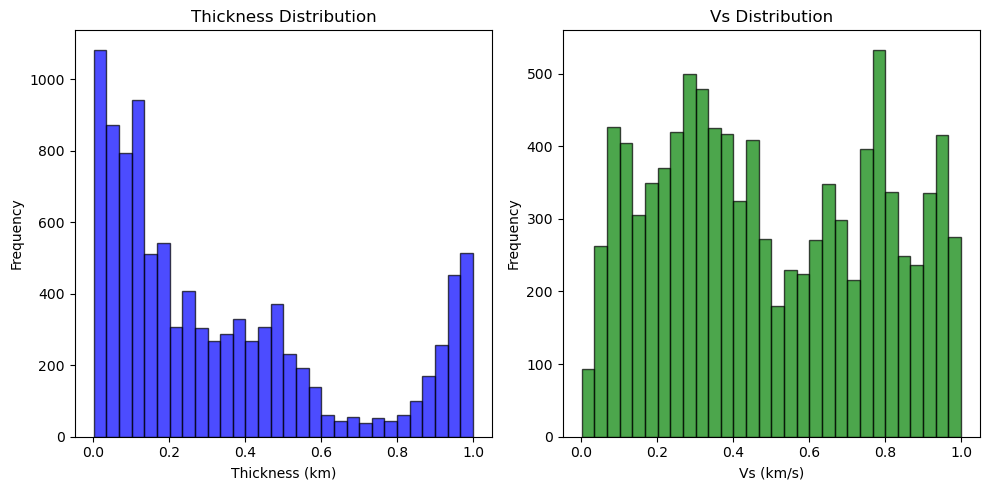

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from subfunctions import forward_disp
# 定义目标函数（likelihood function）
def likelihood(params, observed_periods, observed_velocity, mode):
    """
    计算给定参数下的似然函数。
    目标是最小化残差平方和，即最小化观测值与模型预测值之间的差异。
    """
    try:
        # 正演计算
        model_velocity = forward_disp(params, observed_periods, mode=mode)  
        
        # 残差
        residual = observed_velocity - model_velocity
        
        # 残差平方和作为似然函数
        likelihood_value = -0.5 * np.sum(residual**2)
        
    except Exception as e:
        # 如果forward_disp计算失败，返回无穷大的残差值
        likelihood_value = -np.inf
    
    return likelihood_value

# 定义先验分布（这里使用均匀分布作为示例）
def prior(params, thk_bounds=(0.001, 1.0), vs_bounds=(0.05, 2.5)):
    """
    计算先验分布的对数概率密度。
    假设先验为均匀分布。
    """
    # 假设参数的先验分布为均匀分布
    thk_min, thk_max = thk_bounds
    vs_min, vs_max = vs_bounds
    
    # 对每个参数进行检查，确保在定义的范围内
    if np.all((params[:len(params)//2] >= thk_min) & (params[:len(params)//2] <= thk_max)) and \
       np.all((params[len(params)//2:] >= vs_min) & (params[len(params)//2:] <= vs_max)):
        return 0  # 如果在先验分布范围内，返回对数概率密度为0（即均匀分布的常数部分）
    else:
        return -np.inf  # 如果超出了先验范围，返回负无穷（不被接受）

# Metropolis-Hastings采样
def metropolis_hastings(observed_periods, observed_velocity, mode, x0, n_samples=1000, thk_bounds=(0.001, 1.0), vs_bounds=(0.05, 2.5)):
    """
    使用Metropolis-Hastings算法进行MCMC采样。
    """
    # 初始化链的状态
    current_params = x0  # 初始猜测
    current_likelihood = likelihood(current_params, observed_periods, observed_velocity, mode)
    current_prior = prior(current_params, thk_bounds, vs_bounds)
    current_posterior = current_likelihood + current_prior  # 后验概率（即似然和先验的和）

    # 存储采样结果
    samples = np.zeros((n_samples, len(x0)))

    # 采样过程
    for i in range(n_samples):
        # 提议新的样本（通过随机扰动当前样本）
        proposed_params = current_params + np.random.normal(0, 0.01, size=len(x0))  # 小的扰动
        proposed_likelihood = likelihood(proposed_params, observed_periods, observed_velocity, mode)
        proposed_prior = prior(proposed_params, thk_bounds, vs_bounds)
        proposed_posterior = proposed_likelihood + proposed_prior

        # 计算接受率
        acceptance_ratio = np.exp(proposed_posterior - current_posterior)

        # 根据Metropolis准则决定是否接受提议
        if np.random.rand() < acceptance_ratio:
            current_params = proposed_params
            current_likelihood = proposed_likelihood
            current_prior = proposed_prior
            current_posterior = proposed_posterior

        # 存储当前采样
        samples[i, :] = current_params

    return samples

# 后处理：绘制采样结果
def plot_samples(samples):
    """
    绘制参数采样结果的直方图。
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].hist(samples[:, 0], bins=30, color='b', edgecolor='black', alpha=0.7)
    axes[0].set_title("Thickness Distribution")
    axes[0].set_xlabel("Thickness (km)")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(samples[:, 1], bins=30, color='g', edgecolor='black', alpha=0.7)
    axes[1].set_title("Vs Distribution")
    axes[1].set_xlabel("Vs (km/s)")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# 使用示例：
# 初始参数（假设为层厚和剪切波速）
thk0 = np.array([0.01,0.04])     # km the thickness of the half-space is not needed
vs0  = np.array([0.2, 0.6, 1.1]) # km/s 
x0 = np.r_[thk0, vs0]

n_samples = 10000

# 执行MCMC贝叶斯反演
samples = metropolis_hastings(
    observed_periods=syn_period,
    observed_velocity=syn_velocity,
    mode=0,
    x0=x0,
    n_samples=n_samples,
    thk_bounds=(0.001, 1.0),  # 层厚的范围
    vs_bounds=(0.05, 2.5)    # 剪切波速的范围
)

# 绘制采样结果
plot_samples(samples)

Running MCMC...


100%|██████████| 500/500 [00:04<00:00, 103.68it/s]


最优模型参数： [0.02072116 0.04563286 0.30746479 0.7202305  0.99277031]


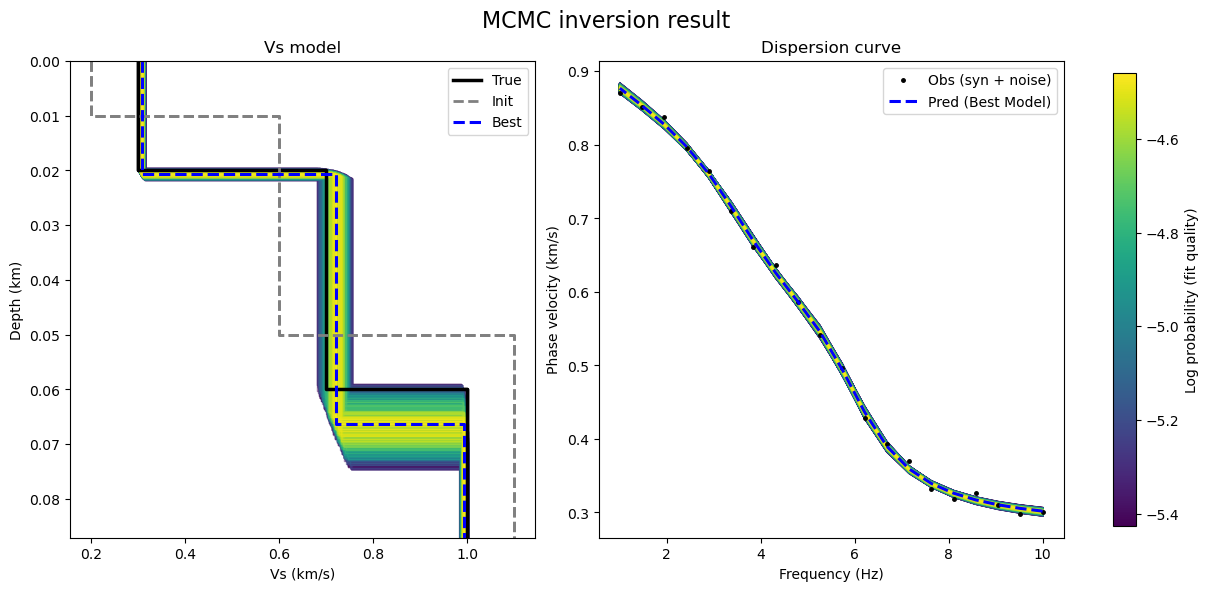

In [ ]:
import numpy as np
import emcee
import matplotlib.pyplot as plt

def log_likelihood(p, observed_periods, observed_velocity, mode, sigma=0.01):
    """
    Log likelihood function for the MCMC inversion.
    """
    try:
        model_velocity = forward_disp(p, observed_periods, mode=mode)  
        residual = observed_velocity - model_velocity
        likelihood_value = -0.5 * np.sum((residual / sigma) ** 2)

    except Exception as e:
        # 如果forward_disp计算失败，返回无穷大的残差值
        likelihood_value = -np.inf
    return likelihood_value

def log_prior(p, thk_bounds=(0.001, 1.0), vs_bounds=(0.05, 2.5)):
    if len(p) % 2 == 0:
        return -np.inf

    n_layers = (len(p) + 1) // 2
    thk = p[:n_layers-1]  # Thickness parameters
    vs = p[n_layers-1:]   # Shear wave velocity parameters

    if np.any(thk < thk_bounds[0]) or np.any(thk > thk_bounds[1]):
        return -np.inf  # Invalid prior if any thickness is out of range
    if np.any(vs < vs_bounds[0]) or np.any(vs > vs_bounds[1]):
        return -np.inf  # Invalid prior if any velocity is out of range
    
    # if np.any(np.diff(vs) < 0):
    #     return -np.inf

    return 0.0  # Flat prior between the defined bounds

def log_probability(p, observed_periods, observed_velocity, mode, sigma=0.01):
    """
    Log posterior function (likelihood + prior).
    """
    lp = log_prior(p)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(p, observed_periods, observed_velocity, mode, sigma=sigma)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

def initialize_walkers(x0, nwalkers, n_layers):

    p0 = np.tile(x0, (nwalkers, 1))
    # Initialize the walkers in a Gaussian distribution around x0
    # choose the perturbation level according to the parameter scale in your case
    p0[:, :n_layers - 1] += 0.02 * np.random.randn(nwalkers, n_layers - 1)
    p0[:, n_layers - 1:] += 0.02 * np.random.randn(nwalkers, n_layers)

    # 
    for i in range(nwalkers):
        while not np.isfinite(log_prior(p0[i])):
            p0[i, :n_layers - 1] = x0[:n_layers - 1] + 0.002 * np.random.randn(n_layers - 1)
            p0[i, n_layers - 1:] = x0[n_layers - 1:] + 0.02 * np.random.randn(n_layers)

    return p0

def run_mcmc(observed_periods, observed_velocity, mode, x0, n_layers, sigma=0.02, nwalkers=100, nsteps=500):
    """
    Run MCMC sampling using emcee.
    """
    ndim = len(x0)
    p0 = initialize_walkers(x0, nwalkers, n_layers)

    # Set up the MCMC sampler
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(observed_periods, observed_velocity, mode, sigma))

    # Run the MCMC chain
    print("Running MCMC...")
    sampler.run_mcmc(p0, nsteps, progress=True)

    # Return the MCMC results
    return sampler

# Example of running MCMC inversion
mode = 0

thk0 = np.array([0.01, 0.04])     # km the thickness of the half-space is not needed
vs0  = np.array([0.2, 0.6, 1.1])  # km/s
n_layers = len(vs0)

x0 = np.r_[thk0, vs0]  # Initial guess for the parameters

# Running the MCMC inversion
sampler = run_mcmc(
    observed_periods=syn_period,
    observed_velocity=syn_velocity,
    mode=mode,
    x0=x0,
    n_layers=n_layers,
    sigma=0.02,
    nwalkers=100,  # Number of walkers
    nsteps=500     # Number of steps per walker
)

# The MCMC chain is stored in the sampler.chain attribute
samples = sampler.get_chain(flat=True)  # 返回所有采样参数
ln_probabilities = sampler.get_log_prob(flat=True)  # 对应的对数似然度（log likelihood）

index = np.argmax(ln_probabilities)
best_model = samples[index]

# 输出最优模型参数
print("最优模型参数：", best_model)

# Convert parameter vectors to thickness/vs for plotting
thk_init, vs_init = sf.params2_thk_vs(x0)
thk_best, vs_best = sf.params2_thk_vs(best_model)

# -----------------------------
# 根据拟合度给所有模型着色
# -----------------------------
# 去掉非有限值
valid = np.isfinite(ln_probabilities)
samples_valid = samples[valid]
lnprob_valid = ln_probabilities[valid]

# 可选：只画拟合较好的那部分，避免图太乱
# 例如取前 20%
#n_show = max(1, int(len(lnprob_valid) * 0.05))
n_show = 5000
sorted_idx = np.argsort(lnprob_valid)[::-1]   # 从高到低
show_idx = sorted_idx[:n_show]

samples_show = samples_valid[show_idx]
lnprob_show = lnprob_valid[show_idx]

# 归一化到 [0, 1]
lnmin, lnmax = np.min(lnprob_show), np.max(lnprob_show)
if lnmax > lnmin:
    fit_norm = (lnprob_show - lnmin) / (lnmax - lnmin)
else:
    fit_norm = np.ones_like(lnprob_show)

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=lnmin, vmax=lnmax)

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), constrained_layout=True)
fig.suptitle("MCMC inversion result", fontsize=16)

# (1) Vs-depth model comparison
ax0 = axes[0]

# 再叠加 true / init / best
depthplot(thk_true, vs_true, ax=ax0,
          plot_args={"color": "k", "linewidth": 2.5, "linestyle": "-"})
depthplot(thk_init, vs_init, ax=ax0,
          plot_args={"color": "gray", "linewidth": 2.0, "linestyle": "--"})
depthplot(thk_best, vs_best, ax=ax0,
          plot_args={"color": "blue", "linewidth": 2.2, "linestyle": "--"})

ax0.set_title("Vs model")
ax0.set_ylim(0.1, 0.0)
ax0.set_xlabel("Vs (km/s)")
ax0.set_ylabel("Depth (km)")
ax0.legend(["True", "Init", "Best"], loc="best")

plot_order = np.argsort(lnprob_show)
samples_plot = samples_show[plot_order]
lnprob_plot = lnprob_show[plot_order]

for p, lp in zip(samples_plot, lnprob_plot):
    color = cmap(norm(lp))
    thk_i, vs_i = sf.params2_thk_vs(p)
    depthplot(
        thk_i, vs_i, ax=ax0,
        plot_args={"color": color, "linewidth": 1.0, "alpha": 0.5}
    )

# 再叠加 true / init / best
depthplot(thk_true, vs_true, ax=ax0,
          plot_args={"color": "k", "linewidth": 2.5, "linestyle": "-"})
depthplot(thk_init, vs_init, ax=ax0,
          plot_args={"color": "gray", "linewidth": 2.0, "linestyle": "--"})
depthplot(thk_best, vs_best, ax=ax0,
          plot_args={"color": "blue", "linewidth": 2.2, "linestyle": "--"})


# (2) Dispersion curve comparison
ax1 = axes[1]

# 画所有采样模型对应的频散曲线
for p, lp in zip(samples_plot, lnprob_plot):
    color = cmap(norm(lp))
    try:
        pred_i = sf.forward_disp(p, syn_period, mode=mode)
        if pred_i is not None and np.all(np.isfinite(pred_i)):
            ax1.plot(1.0 / syn_period, pred_i, color=color, linewidth=1.0, alpha=0.5)
    except Exception:
        pass

# 再叠加观测 / init / best
pred_init = sf.forward_disp(x0, syn_period, mode=mode)
pred_best = sf.forward_disp(best_model, syn_period, mode=mode)

ax1.plot(1.0 / syn_period, syn_velocity, "k.", ms=5, label="Obs (syn + noise)")
# ax1.plot(1.0 / syn_period, pred_init, "r-", linewidth=2.0, label="Pred (init)")
ax1.plot(1.0 / syn_period, pred_best, color="blue", linestyle="--", linewidth=2.2, label="Pred (Best Model)")

ax1.set_title("Dispersion curve")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Phase velocity (km/s)")
ax1.legend(loc="best")

# -----------------------------
# 加 colorbar
# -----------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.95)
cbar.set_label("Log probability (fit quality)")

# Save and show the plot
plt.savefig("MCMC_inversion_result_colored.png", dpi=150)
plt.show()